<a href="https://colab.research.google.com/github/novakai-one/claude-ai-demo/blob/main/notebooks/showpieces/tinylm_retrain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Showpiece B · retrain notebook*

# How does a program learn to write, one character at a time?

> **In short**
>
> **How does a program learn to write, one character at a time?**
>
> Show it a long text and ask it, millions of times, to guess the next character. Each wrong guess nudges its weights. After enough guesses, its own writing looks like the text.

## Where you'll end up

By the end you will have:

1. **Trained the same network as the site's tiny language model**: 5 layers, about a million weights, on Shakespeare's plays.
2. **Made it write** at different temperatures, and **looked at its attention**.
3. **Exported it** in the format the site reads, so you can put your own model on the page.

Training here runs 1,500 steps (the site's model ran 6,000). On Colab's free CPU this takes about 10–15 minutes. The picture below is a real run of this notebook.

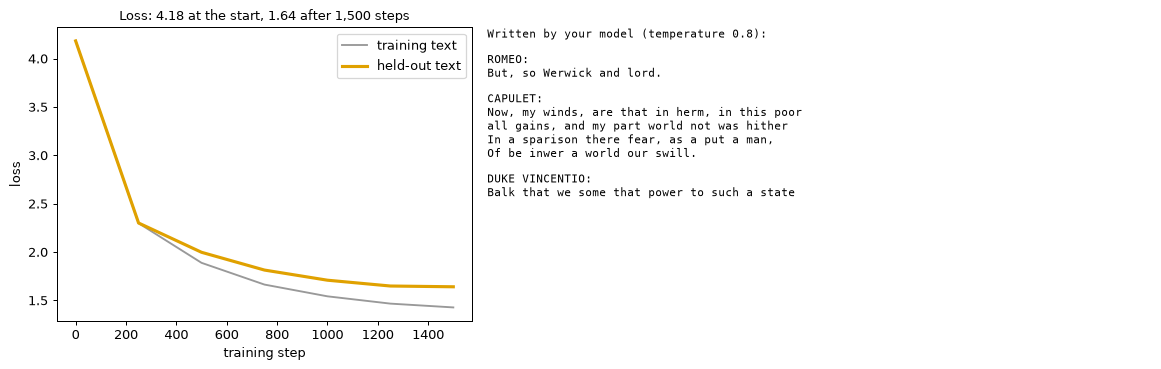

## How to use this notebook

- Run each grey code cell with **Shift + Enter**, top to bottom.
- 🤔 **Predict first** boxes ask you to guess before you run. The answer is one click away.
- 🐍 **Python notes** explain Python as it comes up.
- Exercise solutions are in collapsed cells. In Colab, double-click a solution's title to open it.
- Optional: **Runtime → Change runtime type → T4 GPU** makes training much faster. The code runs on the CPU either way.

## 1. The text, as numbers

The model reads characters, so each different character gets a number. The whole text becomes a long list of numbers.

In [1]:
import urllib.request, math, time, json, base64, os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
try:
    text = urllib.request.urlopen(URL, timeout=30).read().decode("utf-8")
except Exception as e:                                   # no internet: use a local copy, or a short stand-in text
    print("download failed:", e)
    text = open("tinyshakespeare.txt").read() if os.path.exists("tinyshakespeare.txt") else "To be, or not to be.\n" * 2000
chars = sorted(set(text))
stoi = {c: i for i, c in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: "".join(chars[i] for i in ids)
data = torch.tensor(encode(text))
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

print(f"{len(text):,} characters, {len(chars)} different ones:")
print(repr("".join(chars)))
print(encode("ROMEO:"), "->", repr(decode(encode("ROMEO:"))))

1,115,394 characters, 65 different ones:
"\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
[30, 27, 25, 17, 27, 10] -> 'ROMEO:'


🐍 **Python notes**
- `sorted(set(text))`: a `set` keeps one copy of each character; `sorted` puts them in order.
- `{c: i for i, c in enumerate(chars)}` builds a dict from character to number. `enumerate` gives (position, item) pairs.
- `encode = lambda s: [...]` makes a small one-line function. `"".join(...)` glues characters into one string.
- `try: ... except Exception as e:` runs a fallback if the download fails.

## 2. The simplest guess: count what follows what

Before any network: for each character, count which characters follow it in the text. Guess in proportion to those counts.

### 🤔 Predict first

**Loss** measures surprise: $-\ln p$, where $p$ is the probability the model gave the real next character. An even guess among 65 characters scores $\ln 65 \approx 4.17$. **What will counting pairs score?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

**About 2.5.** Knowing only the previous character already removes a lot of surprise. Run the next cell.

</details>

In [2]:
counts = torch.ones(len(chars), len(chars))                 # start every count at 1, so no pair has probability 0
for a, b in zip(train_data[:-1].tolist(), train_data[1:].tolist()):
    counts[a, b] += 1
probs = counts / counts.sum(1, keepdim=True)
v = val_data.tolist()
pair_loss = -np.mean([math.log(probs[a, b]) for a, b in zip(v[:-1], v[1:])])
print(f"even guess: {math.log(len(chars)):.2f}    counting pairs: {pair_loss:.2f}")

even guess: 4.17    counting pairs: 2.48


🐍 `zip(a, b)` walks two lists side by side. `counts.sum(1, keepdim=True)` adds up each row, so dividing makes each row add to 1.

**What you see:** counting pairs scores about 2.5 on held-out text. To do better, a model must use more than one character of context.

## 3. The network

This is the exact code behind the site's model (`training/train_tinylm.py`). Each character becomes a list of 128 numbers.
Five blocks then mix information along the text. In each block, **attention** lets every position take a weighted average of
the positions before it, with weights it computes itself. The last step turns 128 numbers into one score per character.

In [3]:
CFG = dict(n_layer=5, n_head=4, n_embd=128, block=128)

class Block(nn.Module):
    def __init__(self, d: int, n_head: int, block: int):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3 * d)
        self.proj = nn.Linear(d, d)
        self.fc1, self.fc2 = nn.Linear(d, 4 * d), nn.Linear(4 * d, d)
        self.n_head = n_head
        self.register_buffer("mask", torch.tril(torch.ones(block, block)).bool())

    def attend(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        hs = C // self.n_head
        q, k, v = (t.view(B, T, self.n_head, hs).transpose(1, 2) for t in (q, k, v))
        att = (q @ k.transpose(-2, -1)) / math.sqrt(hs)
        att = att.masked_fill(~self.mask[:T, :T], float("-inf")).softmax(-1)
        y = (att @ v).transpose(1, 2).reshape(B, T, C)
        return self.proj(y), att

    def forward(self, x):
        a, att = self.attend(self.ln1(x))
        x = x + a
        x = x + self.fc2(F.gelu(self.fc1(self.ln2(x)), approximate="tanh"))
        return x, att


class TinyLM(nn.Module):
    def __init__(self, vocab: int, n_layer: int, n_head: int, n_embd: int, block: int):
        super().__init__()
        self.tok = nn.Embedding(vocab, n_embd)
        self.pos = nn.Embedding(block, n_embd)
        self.blocks = nn.ModuleList(Block(n_embd, n_head, block) for _ in range(n_layer))
        self.ln_f = nn.LayerNorm(n_embd)
        self.block = block
        for m in self.modules():                            # small starting weights (GPT-2 style)
            if isinstance(m, (nn.Linear, nn.Embedding)):
                nn.init.normal_(m.weight, std=0.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, idx, return_att: bool = False):
        T = idx.shape[1]
        x = self.tok(idx) + self.pos(torch.arange(T))
        atts = []
        for b in self.blocks:
            x, att = b(x)
            atts.append(att)
        logits = self.ln_f(x) @ self.tok.weight.T          # output layer shares the character embedding
        return (logits, atts) if return_att else logits


model = TinyLM(len(chars), **CFG)
print(f"{sum(p.numel() for p in model.parameters()):,} weights")

1,016,320 weights


🐍 **Python notes**
- `class Block(nn.Module):` defines a new kind of object, built on PyTorch's `nn.Module`. `__init__` creates its weights; `forward` says what it computes.
- `super().__init__()` runs `nn.Module`'s own set-up first.
- `masked_fill(~mask, -inf)` hides the future: position 10 can't look at position 11. After `softmax`, hidden positions get weight 0.
- `(t.view(...) for t in (q, k, v))` is a **generator expression**; unpacking it into three names applies the same reshape to all three.

**What it's called:** this design is a *transformer*. Each block has *attention* (4 *heads*, each with its own weights) and a small two-layer network.

## 4. Train it

Each step: take 32 random pieces of 128 characters, ask the model to guess every next character, measure the loss, and nudge all the weights downhill.
This is gradient descent (Field 1) with a better step rule called **AdamW**. The loss is printed every 250 steps, on training text and on held-out text.

In [4]:
torch.manual_seed(0)
model = TinyLM(len(chars), **CFG)
BATCH, STEPS = 32, 1500

def get_batch(split):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - CFG["block"] - 1, (BATCH,))
    x = torch.stack([d[i:i + CFG["block"]] for i in ix])
    y = torch.stack([d[i + 1:i + CFG["block"] + 1] for i in ix])
    return x, y

@torch.no_grad()
def estimate_loss():
    model.eval()
    out = {}
    for split in ("train", "val"):
        out[split] = float(np.mean([F.cross_entropy(model(x).flatten(0, 1), y.flatten()).item()
                                    for x, y in (get_batch(split) for _ in range(20))]))
    model.train()
    return out

opt = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=0.05, betas=(0.9, 0.98))
sched = torch.optim.lr_scheduler.LambdaLR(
    opt, lambda s: min(1, (s + 1) / 200) * (0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * min(1, s / STEPS)))))
curve, t0 = [], time.time()
for step in range(STEPS + 1):
    if step % 250 == 0:
        ev = estimate_loss()
        curve.append((step, ev["train"], ev["val"]))
        print(f"step {step:5d}   training text {ev['train']:.3f}   held-out text {ev['val']:.3f}   {time.time() - t0:.0f}s")
    if step == STEPS:
        break
    x, y = get_batch("train")
    loss = F.cross_entropy(model(x).flatten(0, 1), y.flatten())
    opt.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step(); sched.step()
_ = model.eval()                                          # switch to "use" mode (the _ = stops Jupyter printing the model)

step     0   training text 4.184   held-out text 4.183   2s


step   250   training text 2.299   held-out text 2.301   63s


step   500   training text 1.889   held-out text 1.998   158s


step   750   training text 1.664   held-out text 1.814   215s


step  1000   training text 1.543   held-out text 1.709   252s


step  1250   training text 1.467   held-out text 1.649   307s


step  1500   training text 1.428   held-out text 1.641   359s


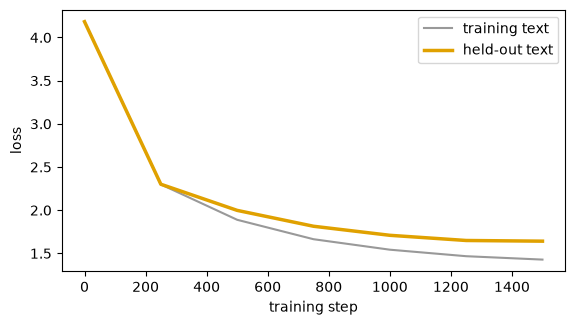

held-out loss: 1.64   (counting pairs: 2.48, even guess: 4.17)


In [5]:
st, tr, va = zip(*curve)
plt.figure(figsize=(6.5, 3.4))
plt.plot(st, tr, color="#999", label="training text")
plt.plot(st, va, color="#e0a100", lw=2.5, label="held-out text")
plt.xlabel("training step"); plt.ylabel("loss"); plt.legend(); plt.show()
print(f"held-out loss: {va[-1]:.2f}   (counting pairs: {pair_loss:.2f}, even guess: {math.log(len(chars)):.2f})")

**What you see:** the loss starts near 4.17 (an even guess), passes the pair-counting score within a few hundred steps, and keeps falling.
The held-out loss is the honest one: it is measured on text the model never trained on.

## 5. Make it write

Writing is a loop: score every character, turn the scores into probabilities, pick one at random, add it, repeat.
The **temperature** $T$ divides the scores first:

$$p_i = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}$$

### 🤔 Predict first

**What will temperature 0.2 do to the text? And temperature 2?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

At 0.2 the top guess wins almost every time, and the text starts to repeat itself. At 2 the probabilities even out, rare characters get picked, and words fall apart. Run the next cell.

</details>

In [6]:
@torch.no_grad()
def write(prompt, n=300, temperature=0.8, seed=1):
    g = torch.Generator().manual_seed(seed)
    idx = torch.tensor([encode(prompt)])
    for _ in range(n):
        logits = model(idx[:, -CFG["block"]:])[0, -1] / temperature    # scores for the next character
        nxt = torch.multinomial(logits.softmax(-1), 1, generator=g)    # pick one, in proportion to probability
        idx = torch.cat([idx, nxt[None]], 1)
    return decode(idx[0].tolist())

for t in (0.2, 0.8, 2.0):
    print(f"----- temperature {t}")
    print(write("ROMEO:\n", 250, t))

----- temperature 0.2


ROMEO:
That shall so shall the comes of the complain,
That is the state of the with a world,
That the seal of the father the seat of the world,
That I do prince the state of my soul,
That thou shalt the prince of the shall be son
The seal of his present the
----- temperature 0.8


ROMEO:
But, so Werwick and lord.

CAPULET:
Now, my winds, are that in herm, in this poor
all gains, and my part world not was hither
In a sparison there fear, as a put a man,
Of be inwer a world our swill.

DUKE VINCENTIO:
Balk that we some that power to su
----- temperature 2.0


ROMEO:
Bouw;'tquers! meauI'l,' that'e, by my misosowrars!

LADUSTAKin Hermonira!Liox, aroal!
WasFe, jets'n, gradgofuf? lordds; gholts be
'Tiss-foidtiErdveds,-Hay!'
Lud-gamhn,mO bok ize, 'Ge'timre let, it
reconcello; thoud, valot, ater is,
Fith jlewetWars,
S


🐍 `@torch.no_grad()` above a function is a **decorator**: it wraps the function so PyTorch doesn't record steps for gradients, which saves time and memory.

**What it's called:** picking at random in proportion to probability is *sampling*. Always picking the top one is *greedy decoding*.

## 6. Look at the attention

For each position, each head has a row of weights over the earlier positions. Here are the weights of every head in the first layer, for one line of text.

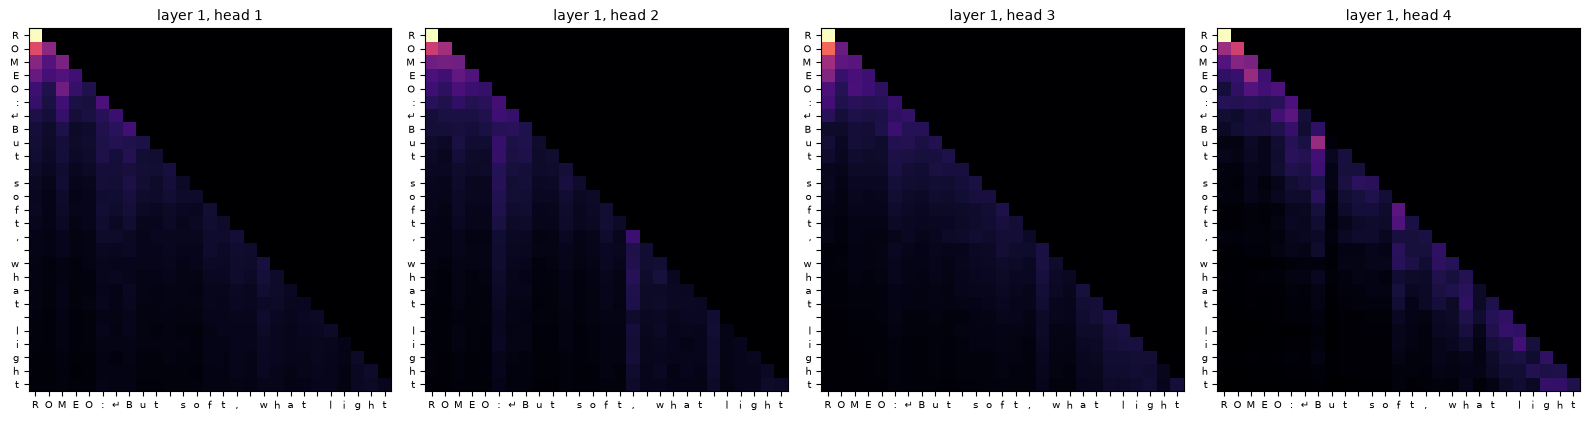

In [7]:
prompt = "ROMEO:\nBut soft, what light"
with torch.no_grad():
    _, atts = model(torch.tensor([encode(prompt)]), return_att=True)
fig, axes = plt.subplots(1, CFG["n_head"], figsize=(16, 4.2))
labels = [c if c != "\n" else "↵" for c in prompt]
for h, ax in enumerate(axes):
    ax.imshow(atts[0][0, h].numpy(), cmap="magma")
    ax.set_xticks(range(len(prompt)), labels, fontsize=7); ax.set_yticks(range(len(prompt)), labels, fontsize=7)
    ax.set_title(f"layer 1, head {h + 1}", fontsize=10)
plt.tight_layout(); plt.show()

**How to read it:** row = the position doing the looking; column = the earlier position it looks at. Bright = more attention. Everything above the diagonal is black: no position can look ahead.

Some heads mostly look one or two characters back. Others spread out over the word or the line. The site's attention view shows the same weights, for any character you click.

## 7. Put your model on the site

The site reads one JSON file. This cell writes your model in that format, as `model.json`.
Download it (Colab's file panel, on the left) and replace `site/public/models/tinylm/model.json` in your copy of the repository.

In [8]:
def b64(t):
    return base64.b64encode(t.detach().numpy().astype(np.float16).tobytes()).decode()

sd = model.state_dict()
KEYS = ["ln1.weight", "ln1.bias", "qkv.weight", "qkv.bias", "proj.weight", "proj.bias",
        "ln2.weight", "ln2.bias", "fc1.weight", "fc1.bias", "fc2.weight", "fc2.bias"]
export = {
    "config": {**CFG, "vocab": len(chars)}, "chars": "".join(chars),
    "params": sum(p.numel() for p in model.parameters()),
    "tok": b64(sd["tok.weight"]), "pos": b64(sd["pos.weight"]),
    "ln_f.weight": b64(sd["ln_f.weight"]), "ln_f.bias": b64(sd["ln_f.bias"]),
    "layers": [{k: b64(sd[f"blocks.{i}.{k}"]) for k in KEYS} for i in range(CFG["n_layer"])],
}
with open("model.json", "w") as f:
    json.dump(export, f)
print(f"wrote model.json ({len(json.dumps(export)) / 1e6:.1f} MB)")

wrote model.json (2.7 MB)


🐍 The weights are saved as 16-bit numbers (`float16`) to halve the file size, then as **base64** text so they fit in JSON. The site turns them back into numbers when the page loads.

## Practice

Try each one before opening its solution.

### Exercise 1

By hand: three characters have scores 2, 1 and 0. **What are their probabilities at temperature 1? At temperature 0.5?**

<details><summary><b>Show the answer to exercise 1</b></summary>

At $T = 1$: $e^2, e^1, e^0 = 7.39, 2.72, 1$; total 11.11; probabilities **0.67, 0.24, 0.09**.

At $T = 0.5$ the scores double to 4, 2, 0: $54.6, 7.39, 1$; total 62.99; probabilities **0.87, 0.12, 0.02**. Lower temperature, sharper choice.

</details>

### Exercise 2

**Make the model write in a different style.** Train it on another text of at least 200,000 characters (a public-domain book, or your own writing), and show a sample.

In [9]:
# your code here

In [ ]:
#@title Solution to exercise 2 (double-click to show)
# Any plain-text file works. For example, a Project Gutenberg book (public domain):
# text = urllib.request.urlopen("https://www.gutenberg.org/cache/epub/1342/pg1342.txt").read().decode("utf-8")
# Then re-run the cells from section 1 (they rebuild chars, encode, data) and sections 3 to 5.
# The vocabulary changes with the text, so the model must be rebuilt, not reused.
print("Replace `text` in section 1, then run sections 1, 3, 4 and 5 again.")

### Exercise 3

Halve the width (`n_embd=64`) and use 2 layers. **How many weights are left? Train it for the same number of steps: how much higher is its held-out loss?**

In [11]:
# your experiment here

In [ ]:
#@title Solution to exercise 3 (double-click to show)
small = TinyLM(len(chars), n_layer=2, n_head=4, n_embd=64, block=128)
print(f"{sum(p.numel() for p in small.parameters()):,} weights")
torch.manual_seed(0)
opt_s = torch.optim.AdamW(small.parameters(), lr=2e-3, weight_decay=0.05, betas=(0.9, 0.98))
for step in range(STEPS):                        # same steps and batches as section 4
    x, y = get_batch("train")
    loss = F.cross_entropy(small(x).flatten(0, 1), y.flatten())
    opt_s.zero_grad(set_to_none=True); loss.backward(); opt_s.step()
small.eval()
with torch.no_grad():
    small_val = float(np.mean([F.cross_entropy(small(x).flatten(0, 1), y.flatten()).item()
                               for x, y in (get_batch("val") for _ in range(20))]))
print(f"held-out loss: small {small_val:.2f}, full {va[-1]:.2f}")
# Fewer weights store fewer patterns of spelling and grammar, so the loss stays higher.

## Recognition cues

- When you see **"generate text one piece at a time"** in a problem, think **a language model: score, pick, repeat**.
- When you see **"more varied" or "more predictable" output** in a problem, think **raise or lower the temperature**.
- When you see **"which earlier words does the model use?"** in a problem, think **look at the attention weights**.
- When you see **training loss falls but held-out loss doesn't** in a problem, think **the model is memorising: more data or a smaller model**.

## Try changing this

1. **Longer training.** Set `STEPS = 6000` (or use a GPU). How low does the held-out loss go?
2. **A shorter memory.** Set `block=32` in `CFG`. What kind of mistakes appear in the writing?
3. **Your own prompt.** Start `write` with a speaker name that isn't in the plays. What does the model do?

## Open research questions

People are working on these right now:

- How do models reason over many steps?
- Why do they sometimes make things up?

Any of them could become a thesis topic.

## Spark Log

Before you close this notebook, write three things about **Language models** in your Spark Log (the Spark Log page on the site):

1. **What surprised me?**
2. **What would I want to know next?**
3. **Excitement, 1 to 10.** How much would you enjoy a year of this?

Write it now, while it's fresh. You will compare fields later.

## Go deeper

- Andrej Karpathy, *Let's build GPT: from scratch, in code, spelled out* (video, about 2 hours). This notebook's model follows the same design: https://www.youtube.com/watch?v=kCc8FmEb1nY
- The site's page for Field 3, *Language models*.